> **역할: [평가기·행정동]**  (전체 순서·최종은 `NOTEBOOK_INDEX.md` / 최종 모델 nb24)

> ⚠️ **데이터 범위(정직)**: 매출은 **상권(자치구·업종·분기) 합계**이고 'per-store'는 **평균**(합계÷점포수)이다. **개별 점포 매출·점포 간 분산 데이터는 없다.** 따라서 (1) 추정 매출은 *상권 평균*이지 신규 점포가 그만큼 번다는 뜻이 아니며, (2) BEP·p_roi(손익분기 초과확률)는 **점포 분산이 아니라 모델 예측오차 기반이라 참고용**이다. **개별 점포 수익·리스크 예측이 아님.**

> ⚠️ **DE-LEAKED 정직본** — 누설 제거 재실행(행정동 110변수). 소표본 데모 신뢰성 한계 유지.

# 09. 좌표 입력 파이프라인 — **행정동 단위 학습 + 신뢰구간**

## 한 줄
**위경도(또는 주소) + 층수 + 업종 + 투자금** → 자치구 자동 매칭 → **행정동 단위 모델**로 점포당 월매출 신뢰구간(P10·P50·P90) 반환.

## v3 변경점

| 항목 | 이전 (자치구 단위) | **지금 (행정동 단위)** |
|---|---|---|
| 학습 표본 | 4,318행 (25 자치구) | **9,172행 (373 행정동)** |
| 점포당 월매출 중앙값 | 237M | **28.7M (현실적)** |
| 점포당 월매출 IQR | 70M ~ 758M | **8M ~ 86M** |
| 표준편차 | 8,995M (이상치 폭주) | **193M (분산 대폭 축소)** |
| 예측 단위 | 25개 자치구 평균 | **373개 행정동 단위** |

→ 행정동 단위가 행정동 평균 점포 분포에 훨씬 가깝다. 사용자 좌표에 매칭된 자치구 안의 행정동 분포를 보여주므로 같은 자치구 안에서도 "어느 동(洞)이 매출 좋은지" 식별 가능.

In [1]:
# === 표준 라이브러리 + 강의 범위만 ===
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt, platform
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
matplotlib.rcParams['font.family'] = 'AppleGothic' if platform.system()=='Darwin' else 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                               HistGradientBoostingRegressor)         # L10 + Quantile Regression

# 경로 상수
PROJECT_ROOT = Path('/Users/ijunsu/Documents/Documents/capston/data_analysis/trade_area_project')
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
GEOJSON_GU      = PROJECT_ROOT / 'data' / 'raw' / 'seoul_districts.geojson'
GEOJSON_ADSTRD  = PROJECT_ROOT / 'data' / 'raw' / 'seoul_adstrd.geojson'   # 신규 수집

# === 행정동 단위 학습 테이블 ===
df = pd.read_csv(PROCESSED_DIR / 'features_adstrd.csv')

# === 자치구 폴리곤 (폴백용) + 행정동 폴리곤 (메인) ===
with open(GEOJSON_GU, encoding='utf-8') as f:
    geo_gu = json.load(f)
with open(GEOJSON_ADSTRD, encoding='utf-8') as f:
    geo_adstrd = json.load(f)

print('features_adstrd:', df.shape)
print(f'자치구 폴리곤: {len(geo_gu["features"])}개')
print(f'행정동 폴리곤: {len(geo_adstrd["features"])}개 (서울)')

features_adstrd: (9172, 126)
자치구 폴리곤: 25개
행정동 폴리곤: 426개 (서울)


## 1. 좌표 → 행정동·자치구 매핑 (pure numpy ray-casting)

3단 매칭 전략:
1. 1순위: **행정동 폴리곤** point-in-polygon → 정확한 동(洞) 매칭
2. 2순위: **자치구 폴리곤** point-in-polygon → 동 GeoJSON 외 영역 폴백
3. 3순위: 가장 가까운 자치구 중심 (서울 외 좌표용)

### 알리아스 매핑 — GeoJSON 동명 vs 학습 데이터 동명 불일치 해소

402개 행정동 중 일부는 GeoJSON과 학습 데이터에서 통합/분리 표기가 달라 직접 매칭이 안 된다.

| GeoJSON | 학습 데이터 | 처리 |
|---|---|---|
| 상일제1동, 상일제2동 | 상일동 (통합) | alias로 치환 |
| 둔촌1동, 암사3동 | 없음 | 자치구 폴백 |
| 반포2동, 반포3동, 서초4동 | 없음 | 자치구 폴백 |

알리아스로 GeoJSON → 학습 동명 사전 매핑을 두면 폴리곤 매칭 결과를 학습 데이터에서 정확히 조회할 수 있다.

In [2]:
# GeoJSON 동명 → 학습 데이터 동명 알리아스 사전
# 추가로 필요한 케이스는 (gu, GeoJSON 동명) 키로 확장 가능
ADSTRD_ALIAS = {
    ('강동구', '상일제1동'): '상일동',
    ('강동구', '상일제2동'): '상일동',
}


def point_in_polygon(x: float, y: float, polygon: list) -> bool:
    """Ray-casting 알고리즘 (외부 GIS 의존 0)."""
    n = len(polygon); inside = False
    p1x, p1y = polygon[0]
    for i in range(1, n + 1):
        p2x, p2y = polygon[i % n]
        if y > min(p1y, p2y) and y <= max(p1y, p2y) and x <= max(p1x, p2x):
            if p1y != p2y:
                xinters = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
                if p1x == p2x or x <= xinters:
                    inside = not inside
        p1x, p1y = p2x, p2y
    return inside


def match_location(lat: float, lon: float) -> dict:
    """좌표 → (행정동, 자치구). 3단 폴백.

    Returns dict:
        level: 'adstrd' / 'gu' / 'nearest'
        gu, adstrd_nm (있으면)
        warnings: 경고 메시지 리스트
    """
    warnings = []

    # 1순위 — 행정동 폴리곤 point-in-polygon
    for feat in geo_adstrd['features']:
        p = feat['properties']
        geom = feat['geometry']
        polys = [geom['coordinates']] if geom['type'] == 'Polygon' else geom['coordinates']
        for poly in polys:
            if point_in_polygon(lon, lat, poly[0]):
                geo_dong = p['dong_nm']
                gu = p['gu_nm']
                # 알리아스 적용: GeoJSON 동명 → 학습 데이터 동명
                data_dong = ADSTRD_ALIAS.get((gu, geo_dong), geo_dong)
                if data_dong != geo_dong:
                    warnings.append(f'동명 알리아스 적용: GeoJSON "{geo_dong}" → 학습 "{data_dong}"')
                return {'level': 'adstrd', 'gu': gu,
                        'adstrd_nm': data_dong,           # 학습 데이터 조회용 이름
                        'adstrd_nm_geojson': geo_dong,    # GeoJSON 원본 이름 (보고용)
                        'warnings': warnings}

    # 2순위 — 자치구 폴리곤
    for feat in geo_gu['features']:
        name = feat['properties'].get('SIG_KOR_NM') or feat['properties'].get('name')
        geom = feat['geometry']
        polys = [geom['coordinates']] if geom['type'] == 'Polygon' else geom['coordinates']
        for poly in polys:
            if point_in_polygon(lon, lat, poly[0]):
                warnings.append('행정동 폴리곤 매칭 실패 → 자치구만 매칭')
                return {'level': 'gu', 'gu': name, 'adstrd_nm': None,
                        'warnings': warnings}

    # 3순위 — 가장 가까운 자치구 중심
    best_name, best_dist = None, float('inf')
    for feat in geo_gu['features']:
        name = feat['properties'].get('SIG_KOR_NM') or feat['properties'].get('name')
        geom = feat['geometry']
        polys = [geom['coordinates']] if geom['type'] == 'Polygon' else geom['coordinates']
        coords = np.array(polys[0][0])
        cx, cy = coords[:,0].mean(), coords[:,1].mean()
        d = (cx - lon)**2 + (cy - lat)**2
        if d < best_dist:
            best_dist, best_name = d, name
    warnings.append(f'서울 폴리곤 외부 좌표 → 최근접 자치구 "{best_name}" 사용')
    return {'level': 'nearest', 'gu': best_name, 'adstrd_nm': None, 'warnings': warnings}


# 시연 — 정확한 행정동까지 매칭되는지
test_points = [('강남역',       37.4979, 127.0276),
                ('홍대입구',      37.5563, 126.9223),
                ('종로3가',       37.5710, 126.9925),
                ('성수역',        37.5446, 127.0559),
                ('잠실역',        37.5133, 127.1000),
                ('상암 DMC',     37.5790, 126.8910),
                ('강동 상일동',   37.5567, 127.1664),   # 상일제1·2동 → 알리아스로 학습 '상일동' 변환
                ('강동 둔촌1동',  37.5316, 127.1374),   # GeoJSON엔 있지만 학습 데이터 없음 → 자치구 폴백
                ('서초 도곡 인근', 37.4900, 127.0440),   # 학습 데이터의 도곡1동은 서초구 분류 → 폴리곤 매칭 결과 확인
                ('서울 외',       37.5034, 126.7660)]
for label, lat, lon in test_points:
    r = match_location(lat, lon)
    dong = r['adstrd_nm'] or '-'
    geo_dong = r.get('adstrd_nm_geojson')
    alias_note = f' (GeoJSON: {geo_dong})' if geo_dong and geo_dong != dong else ''
    print(f'{label:14s} → {r["gu"]:6s} {dong:10s}{alias_note} [{r["level"]}]')

강남역            → 서초구    서초2동       [adstrd]
홍대입구           → 마포구    서교동        [adstrd]
종로3가           → 종로구    종로1·2·3·4가동 [adstrd]
성수역            → 성동구    성수2가3동     [adstrd]
잠실역            → 송파구    잠실3동       [adstrd]
상암 DMC         → 마포구    상암동        [adstrd]
강동 상일동         → 강동구    상일동        (GeoJSON: 상일제1동) [adstrd]
강동 둔촌1동        → 강동구    성내3동       [adstrd]
서초 도곡 인근       → 강남구    도곡1동       [adstrd]
서울 외           → 강서구    -          [nearest]


## 2. 주소 → 좌표 (Kakao API 골격)

In [3]:
import os
from urllib.request import urlopen, Request
from urllib.error import URLError, HTTPError
from urllib.parse import quote

KAKAO_API_KEY = os.getenv('KAKAO_REST_API_KEY', '')

def geocode_kakao(query: str, kind: str = 'address'):
    """주소/상가명 → 위경도. API 키 없으면 None."""
    if not KAKAO_API_KEY: return None
    endpoint = {'address':'https://dapi.kakao.com/v2/local/search/address.json',
                 'keyword':'https://dapi.kakao.com/v2/local/search/keyword.json'}[kind]
    url = f'{endpoint}?query={quote(query)}'
    req = Request(url, headers={'Authorization': f'KakaoAK {KAKAO_API_KEY}'})
    try:
        with urlopen(req, timeout=10) as resp:
            data = json.loads(resp.read().decode('utf-8'))
        if not data.get('documents'): return None
        doc = data['documents'][0]
        return {'lat': float(doc['y']), 'lon': float(doc['x']),
                'address_name': doc.get('address_name') or doc.get('place_name'),
                'multiple': len(data['documents']) > 1}
    except (URLError, HTTPError, json.JSONDecodeError):
        return None

print('KAKAO_API_KEY 존재:', bool(KAKAO_API_KEY))

KAKAO_API_KEY 존재: False


## 3. 층수 보정 계수 (설계서 §3.1)

In [4]:
FLOOR_MULTIPLIER = {
    'food':    {'1F':1.00,'B1':0.55,'2F':0.65,'3F+':0.45,'high':0.30},
    'retail':  {'1F':1.00,'B1':0.50,'2F':0.55,'3F+':0.35,'high':0.20},
    'service': {'1F':1.00,'B1':0.70,'2F':0.95,'3F+':0.90,'high':0.85},
    'other':   {'1F':1.00,'B1':0.60,'2F':0.75,'3F+':0.60,'high':0.50},
}
BIZ_TO_GROUP = {
    '한식음식점':'food','커피-음료':'food','양식음식점':'food','일식음식점':'food','호프-간이주점':'food',
    '편의점':'retail','슈퍼마켓':'retail','반찬가게':'retail','일반의류':'retail',
    '수산물판매':'retail','컴퓨터및주변장치판매':'retail',
    '의약품':'service','일반의원':'service',
}

def normalize_floor(s):
    s = str(s).strip().lower()
    if any(k in s for k in ['지하','b1','b2','basement']): return 'B1'
    if '1' in s and ('층' in s or 'f' in s) and '11' not in s and '21' not in s: return '1F'
    if '2' in s and ('층' in s or 'f' in s): return '2F'
    if any(k in s for k in ['3층','4층','5층','6층','7층','8층','9층','3f','4f','5f','6f','7f','8f','9f']): return '3F+'
    if any(k in s for k in ['고층','옥탑','rooftop']) or '10' in s: return 'high'
    if s.isdigit():
        n = int(s)
        if n == 1: return '1F'
        if n == 2: return '2F'
        if n >= 10: return 'high'
        if n >= 3:  return '3F+'
    return '1F'

def floor_factor(biz, floor_norm):
    return FLOOR_MULTIPLIER[BIZ_TO_GROUP.get(biz, 'other')].get(floor_norm, 1.00)

## 4. 모델 학습 — 행정동 단위 + Quantile Regression

In [5]:
# 입력 변수 선정 — 식별자/타깃 제외
id_cols = ['adstrd_code','adstrd_nm','gu','biz','q','q_int']
target_excluded = ['adstrd_sales_amt','log_sales','sales_per_store','log_sales_per_store','store_class']
feature_cols = [c for c in df.columns if c not in id_cols + target_excluded]
feature_cols = [c for c in feature_cols if c not in ['avg_ticket','peer_avg_sales','momentum','margin_proxy','rent_to_sales']]  # de-leak(feature_cols)
print(f'행정동 단위 입력 변수: {len(feature_cols)}개')

target_reg = 'log_sales_per_store'
target_cls = 'store_class'

# 결측 처리 + 숫자 변환 (안전하게 컬럼별 루프)
for c in feature_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].mean(numeric_only=True))

X_all = df[feature_cols].values

# 분류기 (low/mid/high)
rf_cls = RandomForestClassifier(n_estimators=300, max_depth=14, random_state=42, n_jobs=-1)
rf_cls.fit(X_all, df[target_cls].values)
print(f'분류기 학습 완료. 클래스: {rf_cls.classes_}')

# 점추정 회귀기 (참고용)
rf_reg = RandomForestRegressor(n_estimators=300, max_depth=14, random_state=42, n_jobs=-1)
rf_reg.fit(X_all, df[target_reg].values)
sigma_log = float(np.std(df[target_reg].values - rf_reg.predict(X_all)))
print(f'점추정 회귀기 학습 완료. σ = {sigma_log:.3f}')

# Quantile Regression 3종 (P10·P50·P90)
quantile_models = {}
for q in [0.10, 0.50, 0.90]:
    m = HistGradientBoostingRegressor(loss='quantile', quantile=q,
                                       max_depth=8, max_iter=400,
                                       learning_rate=0.1, random_state=42)
    m.fit(X_all, df[target_reg].values)
    quantile_models[q] = m
    print(f'  Q{int(q*100):02d} 학습 완료')

all_log_sales = df[target_reg].values


# === 자치구 폴백 모델 — features.csv (50업종, 자치구·업종·분기) ===
# 행정동 데이터에 없는 업종(team3 10개 외)을 위한 폴백
df_gu = pd.read_csv(PROCESSED_DIR / 'features.csv')
id_cols_gu = ['gu','biz','q','q_int']
target_excluded_gu = ['THSMON_SELNG_AMT','log_sales','sales_class',
                       'sales_per_store','log_sales_per_store','store_class']
feature_cols_gu = [c for c in df_gu.columns if c not in id_cols_gu + target_excluded_gu]
feature_cols_gu = [c for c in feature_cols_gu if c not in ['avg_ticket','peer_avg_sales','momentum','margin_proxy','rent_to_sales']]  # de-leak(feature_cols_gu)
for c in feature_cols_gu:
    df_gu[c] = pd.to_numeric(df_gu[c], errors='coerce')
df_gu[feature_cols_gu] = df_gu[feature_cols_gu].fillna(df_gu[feature_cols_gu].mean(numeric_only=True))

X_gu = df_gu[feature_cols_gu].values
quantile_models_gu = {}
for q in [0.10, 0.50, 0.90]:
    m = HistGradientBoostingRegressor(loss='quantile', quantile=q,
                                       max_depth=8, max_iter=400,
                                       learning_rate=0.1, random_state=42)
    m.fit(X_gu, df_gu['log_sales_per_store'].values)
    quantile_models_gu[q] = m

rf_cls_gu = RandomForestClassifier(n_estimators=300, max_depth=14, random_state=42, n_jobs=-1)
rf_cls_gu.fit(X_gu, df_gu['store_class'].values)

biz_in_adstrd = set(df['biz'].unique())
biz_only_in_gu = set(df_gu['biz'].unique()) - biz_in_adstrd
print(f'\n자치구 폴백 모델 (50업종) 학습 완료')
print(f'  행정동 모델 커버: {len(biz_in_adstrd)}개 업종')
print(f'  자치구 폴백 전용: {len(biz_only_in_gu)}개 업종 (예: {sorted(biz_only_in_gu)[:5]})')

행정동 단위 입력 변수: 110개


분류기 학습 완료. 클래스: ['high' 'low' 'mid']


점추정 회귀기 학습 완료. σ = 0.973


  Q10 학습 완료


  Q50 학습 완료


  Q90 학습 완료



자치구 폴백 모델 (50업종) 학습 완료
  행정동 모델 커버: 50개 업종
  자치구 폴백 전용: 0개 업종 (예: [])


## 5. 점포당 매출 분포 시각화 (행정동 단위)

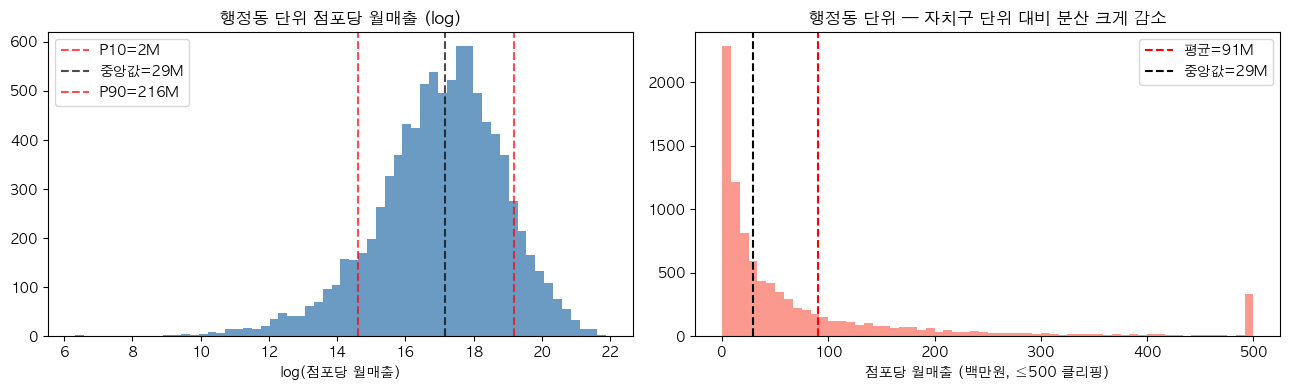

행정동 단위: 평균 90.7M vs 중앙값 28.7M, std=193.2M


In [6]:
# 그래프 1 — 점포당 월매출 히스토그램 (log)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sales_M = np.exp(df[target_reg]) / 1e6
axes[0].hist(df[target_reg], bins=60, color='steelblue', alpha=0.8)
for q, lab, c in [(0.10,'P10','red'),(0.50,'중앙값','black'),(0.90,'P90','red')]:
    v = np.quantile(df[target_reg], q)
    axes[0].axvline(v, color=c, linestyle='--', alpha=0.7, label=f'{lab}={np.exp(v)/1e6:.0f}M')
axes[0].set_xlabel('log(점포당 월매출)'); axes[0].set_title('행정동 단위 점포당 월매출 (log)')
axes[0].legend()

axes[1].hist(sales_M.clip(upper=500), bins=60, color='salmon', alpha=0.8)
axes[1].axvline(sales_M.mean(), color='red', linestyle='--', label=f'평균={sales_M.mean():.0f}M')
axes[1].axvline(sales_M.median(), color='black', linestyle='--', label=f'중앙값={sales_M.median():.0f}M')
axes[1].set_xlabel('점포당 월매출 (백만원, ≤500 클리핑)')
axes[1].set_title('행정동 단위 — 자치구 단위 대비 분산 크게 감소')
axes[1].legend()
plt.tight_layout(); plt.show()
print(f'행정동 단위: 평균 {sales_M.mean():.1f}M vs 중앙값 {sales_M.median():.1f}M, std={sales_M.std():.1f}M')

/tmp/claude-501/ipykernel_14502/822001360.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=gu_order, showfliers=False)


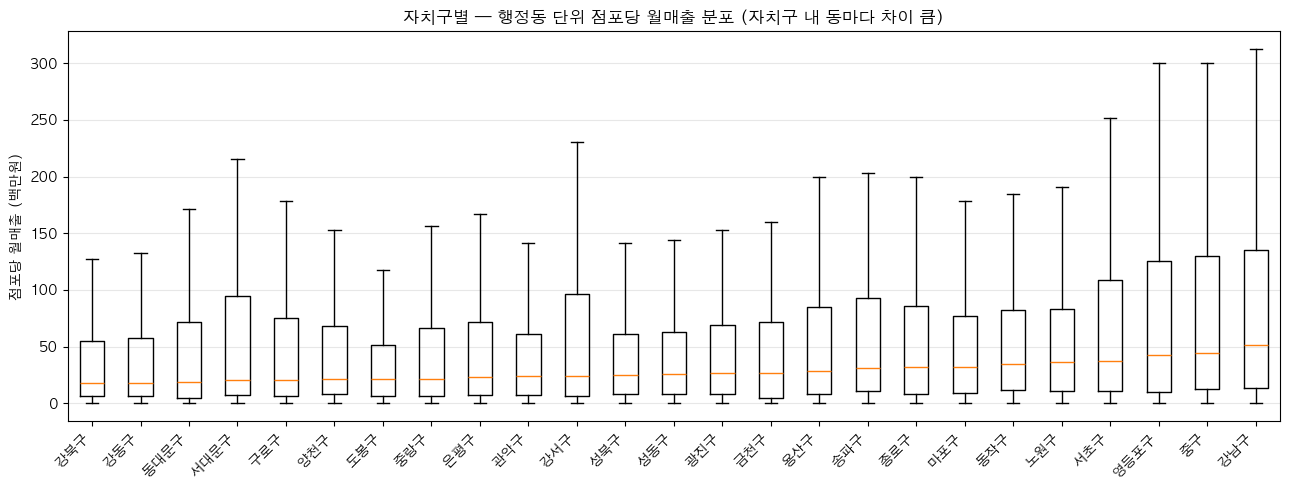

In [7]:
# 그래프 2 — 자치구별 행정동 분포 (자치구 안의 행정동들이 얼마나 흩어져 있는지)
gu_order = df.groupby('gu')[target_reg].median().sort_values().index.tolist()
data = [np.exp(df.loc[df['gu']==g, target_reg])/1e6 for g in gu_order]
fig, ax = plt.subplots(figsize=(13, 5))
ax.boxplot(data, labels=gu_order, showfliers=False)
ax.set_ylabel('점포당 월매출 (백만원)')
ax.set_title('자치구별 — 행정동 단위 점포당 월매출 분포 (자치구 내 동마다 차이 큼)')
plt.xticks(rotation=45, ha='right'); plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

/tmp/claude-501/ipykernel_14502/3817711636.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=biz_order, showfliers=False)


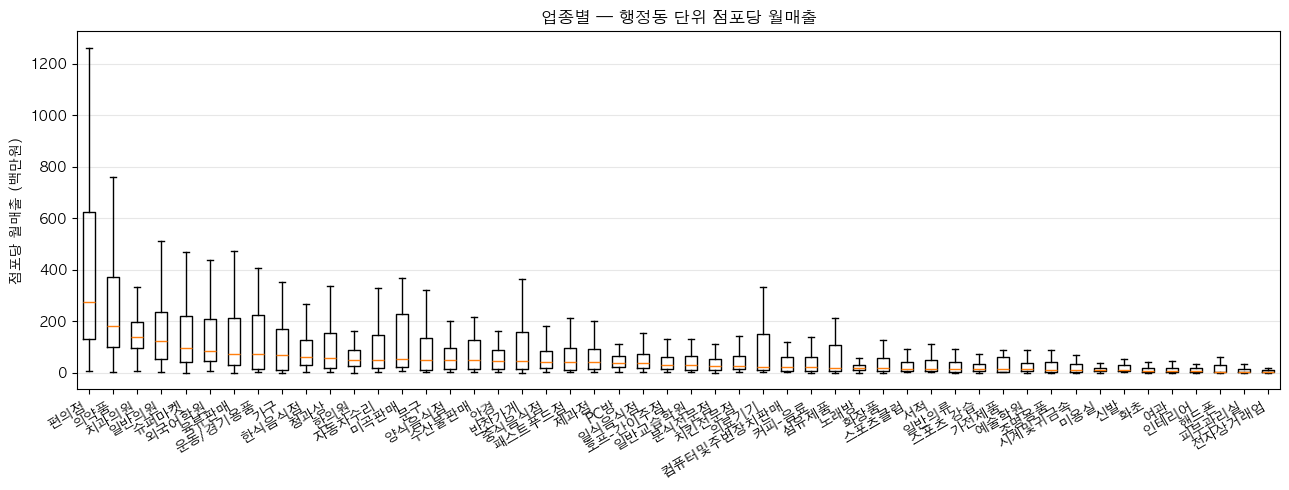

In [8]:
# 그래프 3 — 업종별 행정동 분포
biz_order = df.groupby('biz')[target_reg].median().sort_values(ascending=False).index.tolist()
data = [np.exp(df.loc[df['biz']==b, target_reg])/1e6 for b in biz_order]
fig, ax = plt.subplots(figsize=(13, 5))
ax.boxplot(data, labels=biz_order, showfliers=False)
ax.set_ylabel('점포당 월매출 (백만원)')
ax.set_title('업종별 — 행정동 단위 점포당 월매출')
plt.xticks(rotation=30, ha='right'); plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

## 6. `evaluate_startup_point()` — 행정동 분포 기반 평가

좌표 → 자치구 매칭 후, **그 자치구·업종에 속한 모든 행정동(최근 분기)**의 점포당 매출 P50 예측을 수집해 분포로 보여준다. 사용자가 자치구 안에서도 매출 좋은 동(洞) 을 식별 가능.

In [9]:
# === 가맹점 실증 데이터 우선 + 도메인 추정 폴백 (11번 노트북에서 생성) ===
import json
INDUSTRY_PARAMS_FALLBACK = {
    '한식음식점':         {'margin_rate':0.20,'standard_invest':100_000_000,'labor_monthly':6_000_000},
    '커피-음료':          {'margin_rate':0.20,'standard_invest':100_000_000,'labor_monthly':6_000_000},
    '양식음식점':         {'margin_rate':0.20,'standard_invest':120_000_000,'labor_monthly':7_000_000},
    '호프-간이주점':       {'margin_rate':0.20,'standard_invest':100_000_000,'labor_monthly':6_000_000},
    '편의점':            {'margin_rate':0.25,'standard_invest': 80_000_000,'labor_monthly':4_000_000},
    '슈퍼마켓':          {'margin_rate':0.25,'standard_invest': 80_000_000,'labor_monthly':4_000_000},
    '반찬가게':          {'margin_rate':0.25,'standard_invest': 50_000_000,'labor_monthly':4_000_000},
    '의약품':            {'margin_rate':0.40,'standard_invest':150_000_000,'labor_monthly':8_000_000},
    '일반의류':           {'margin_rate':0.30,'standard_invest': 80_000_000,'labor_monthly':4_000_000},
    '컴퓨터및주변장치판매': {'margin_rate':0.20,'standard_invest': 80_000_000,'labor_monthly':4_000_000},
    '미용실':            {'margin_rate':0.35,'standard_invest': 70_000_000,'labor_monthly':4_000_000},
    '일반의원':           {'margin_rate':0.40,'standard_invest':200_000_000,'labor_monthly':10_000_000},
    '치킨전문점':         {'margin_rate':0.25,'standard_invest': 80_000_000,'labor_monthly':4_000_000},
    '분식전문점':         {'margin_rate':0.25,'standard_invest': 50_000_000,'labor_monthly':4_000_000},
    '노래방':            {'margin_rate':0.30,'standard_invest': 60_000_000,'labor_monthly':3_000_000},
}

# 가맹점 실증 데이터 로드 — 11번 노트북에서 생성된 json
EVIDENCE_PATH = PROCESSED_DIR / 'industry_params_evidence.json'
INDUSTRY_PARAMS_EVIDENCE = {}
if EVIDENCE_PATH.exists():
    with open(EVIDENCE_PATH, encoding='utf-8') as f:
        INDUSTRY_PARAMS_EVIDENCE = json.load(f)
    print(f'가맹점 실증 데이터 로드: {len(INDUSTRY_PARAMS_EVIDENCE)}개 업종')
else:
    print('industry_params_evidence.json 없음 — 도메인 폴백만 사용')

def get_industry_params(biz: str) -> dict:
    """실증 데이터 우선, 없으면 도메인 추정 폴백."""
    if biz in INDUSTRY_PARAMS_EVIDENCE:
        p = dict(INDUSTRY_PARAMS_EVIDENCE[biz])
        p['source'] = 'team1 가맹점 실증 (중앙값)'
        return p
    if biz in INDUSTRY_PARAMS_FALLBACK:
        p = dict(INDUSTRY_PARAMS_FALLBACK[biz])
        p['source'] = '도메인 추정 (폴백)'
        return p
    return {'margin_rate':0.25,'standard_invest':80_000_000,'labor_monthly':4_000_000,
             'source':'기본값 (업종 미등록)'}

def evaluate_startup_point(*, lat=None, lon=None, address=None, place_name=None,
                            biz: str, floor: str='1F', investment: int=None):
    """좌표 + 업종 + 층수 + 투자금 → 행정동 단위 점포당 월매출 신뢰구간 + 자치구 내 행정동 분포."""
    warnings = []

    # 1. 좌표 확보
    if lat is not None and lon is not None:
        pass
    elif address:
        r = geocode_kakao(address, 'address')
        if r is None: return {'error': '지오코딩 실패 (Kakao 키 없거나 결과 없음)'}, None
        lat, lon = r['lat'], r['lon']; warnings.append(f'주소→좌표: {r["address_name"]}')
    elif place_name:
        r = geocode_kakao(place_name, 'keyword')
        if r is None: return {'error': '키워드 검색 실패'}, None
        lat, lon = r['lat'], r['lon']
    else:
        return {'error': 'lat/lon, address, place_name 중 하나는 필요'}, None

    # 2. 행정동/자치구 매칭 (3단 폴백)
    spatial = match_location(lat, lon)
    gu = spatial['gu']
    matched_adstrd = spatial['adstrd_nm']
    warnings.extend(spatial['warnings'])

    # 2.5. 업종 전역 표본 부족 검사 — 행정동·자치구 양쪽에서 학습 표본 작으면 경고
    n_biz_adstrd = (df['biz'] == biz).sum()
    n_biz_gu     = (df_gu['biz'] == biz).sum()
    if n_biz_adstrd < 30 and biz in biz_in_adstrd:
        warnings.append(f'⚠️ 업종 "{biz}" 행정동 학습 표본 {n_biz_adstrd}행 (30 미만) — 예측 신뢰도 낮음')
    if n_biz_gu < 30:
        warnings.append(f'⚠️ 업종 "{biz}" 자치구 학습 표본 {n_biz_gu}행 (30 미만) — 예측 신뢰도 매우 낮음')

    # 3. 업종이 행정동 모델 학습 범위에 있는지 확인
    if biz not in biz_in_adstrd:
        # → 자치구 50업종 폴백 모델 사용 (행정동 데이터에 없는 업종)
        warnings.append(f'업종 "{biz}" 행정동 데이터 없음 → 자치구 폴백 모델 (50업종) 사용')
        sub_gu = df_gu[(df_gu['gu'] == gu) & (df_gu['biz'] == biz)]
        if sub_gu.empty:
            return {'error': f'데이터 없음: gu={gu}, biz={biz}', 'warnings': warnings}, None
        # (gu, biz) 조합 표본 부족도 체크
        if len(sub_gu) < 10:
            warnings.append(f'⚠️ (gu={gu}, biz={biz}) 자치구·분기 표본 {len(sub_gu)}행 — 매우 부족')
        latest_q_gu = sub_gu['q_int'].max()
        row_gu = sub_gu[sub_gu['q_int'] == latest_q_gu].iloc[0]

        # 자치구 모델 Quantile 예측
        floor_norm = normalize_floor(floor); f_mult = floor_factor(biz, floor_norm)
        log_floor_adj = np.log(max(f_mult, 1e-3))
        x_gu = row_gu[feature_cols_gu].values.reshape(1, -1)
        log_p10 = float(quantile_models_gu[0.10].predict(x_gu)[0]) + log_floor_adj
        log_p50 = float(quantile_models_gu[0.50].predict(x_gu)[0]) + log_floor_adj
        log_p90 = float(quantile_models_gu[0.90].predict(x_gu)[0]) + log_floor_adj
        proba = rf_cls_gu.predict_proba(x_gu)[0]
        cls_proba = dict(zip(rf_cls_gu.classes_, np.round(proba, 3)))

        # BEP
        params = get_industry_params(biz)
        invest = investment if investment is not None else params['standard_invest']
        rent_proxy = float(row_gu.get('rent_index_q', 100)) * 50_000
        bep = (rent_proxy + params['labor_monthly'] + invest/36) / params['margin_rate']

        if log_p90 <= log_p10 or bep <= 0:
            p_roi = 0.5
        else:
            pos = max(0.0, min(1.0, (np.log(bep) - log_p10) / (log_p90 - log_p10)))
            p_roi = 1.0 - pos

        p_high = cls_proba.get('high', 0)

        # === 자치구 폴백 모델의 포화도 (자치구·업종 평균 점포 밀도) ===
        stor_col = 'STOR_CO' if 'STOR_CO' in row_gu.index else None
        rep_stor_gu = float(row_gu[stor_col]) if stor_col else 0
        stor_all = df_gu[df_gu['biz']==biz].sort_values('q_int').drop_duplicates('gu', keep='last')['STOR_CO'] if 'STOR_CO' in df_gu.columns else None
        if stor_all is not None and len(stor_all) >= 3:
            saturation_pct = float((stor_all < rep_stor_gu).mean())
        else:
            saturation_pct = 0.5
        if   saturation_pct >= 0.80: sat_grade = '🔴 포화 (경쟁 심함)'
        elif saturation_pct >= 0.50: sat_grade = '🟡 적정'
        elif saturation_pct >= 0.20: sat_grade = '🟢 저밀도'
        else:                        sat_grade = '🟢 미개척'
        sat_penalty = max(0, saturation_pct - 0.5) * 0.30

        raw_sr = 0.40*p_high + 0.40*p_roi + 0.20*0.5
        adj_sr = max(0, raw_sr - sat_penalty)

        return {
            'input': {'lat': lat, 'lon': lon, 'biz': biz, 'floor': floor_norm,
                      'floor_multiplier': f_mult, 'investment_KRW': int(invest)},
            'matched_area': {'level': 'gu (50biz fallback)', 'gu': gu,
                              'matched_adstrd': None, 'n_adstrd_in_gu_biz': 0,
                              'representative_adstrd': None},
            'monthly_sales_estimate_per_avg_store': {
                'P10_pessimistic': round(np.exp(log_p10), 0),
                'P50_median':      round(np.exp(log_p50), 0),
                'P90_optimistic':  round(np.exp(log_p90), 0),
            },
            'saturation': {
                'my_store_count':         int(rep_stor_gu),
                'saturation_percentile':  round(saturation_pct, 3),
                'saturation_grade':       sat_grade,
                'saturation_penalty_pct': round(sat_penalty * 100, 1),
                'raw_success_rate':       round(raw_sr * 100, 1),
            },
            'predicted_class': str(rf_cls_gu.predict(x_gu)[0]),
            'class_probabilities': cls_proba,
            'breakeven_monthly_sales': round(bep, 0),
            'p_roi': round(p_roi, 3),
            'success_rate': round(adj_sr, 3),
            'context': {'rent_index_q': float(row_gu.get('rent_index_q', np.nan)),
                         'vacancy_rate': float(row_gu.get('vacancy_rate', np.nan))},
            'note': '행정동 모델 학습 범위 외 업종 → 자치구·업종·분기 단위 모델 사용',
            'warnings': warnings,
        }, None    # 두 번째 반환은 분포 DataFrame — 자치구 폴백엔 없음

    # 4. (행정동 모델 사용) 학습 데이터에서 후보 행 추출
    if spatial['level'] == 'adstrd' and matched_adstrd:
        sub = df[(df['gu'] == gu) & (df['adstrd_nm'] == matched_adstrd) & (df['biz'] == biz)]
        if sub.empty:
            warnings.append(f'행정동 "{matched_adstrd}" 학습 데이터 없음 → 자치구 내 행정동 폴백')
            sub = df[(df['gu'] == gu) & (df['biz'] == biz)]
            spatial['level'] = 'gu (fallback from adstrd)'
            matched_adstrd = None
    else:
        sub = df[(df['gu'] == gu) & (df['biz'] == biz)]

    if sub.empty:
        return {'error': f'데이터 없음: gu={gu}, biz={biz}', 'warnings': warnings}, None

    # (gu, biz) 단위 학습 표본 점검
    n_pairs = len(sub)
    if n_pairs < 30:
        warnings.append(f'⚠️ (gu={gu}, biz={biz}) 행정동·분기 표본 {n_pairs}행 — 예측 분산 클 수 있음')
    if n_pairs < 10:
        warnings.append(f'⚠️ (gu={gu}, biz={biz}) 표본 매우 부족 ({n_pairs}행) — 결과 참고용')

    latest_q = sub['q_int'].max()
    sub_latest = sub[sub['q_int'] == latest_q].copy()
    n_dong = len(sub_latest)

    # 4. 층수 보정
    floor_norm = normalize_floor(floor)
    f_mult = floor_factor(biz, floor_norm)
    log_floor_adj = np.log(max(f_mult, 1e-3))

    # 5. 각 행정동에 대해 Quantile 예측 (P10, P50, P90)
    X_dong = sub_latest[feature_cols].values
    log_p10 = quantile_models[0.10].predict(X_dong) + log_floor_adj
    log_p50 = quantile_models[0.50].predict(X_dong) + log_floor_adj
    log_p90 = quantile_models[0.90].predict(X_dong) + log_floor_adj
    sub_latest['est_P10'] = np.exp(log_p10)
    sub_latest['est_P50'] = np.exp(log_p50)
    sub_latest['est_P90'] = np.exp(log_p90)

    # 6. 자치구 내 행정동들의 분포 요약 (행정동 P50들의 분위)
    dist = sub_latest[['adstrd_nm','est_P10','est_P50','est_P90']].copy()
    dist_sorted = dist.sort_values('est_P50', ascending=False).reset_index(drop=True)

    # 자치구 안에서의 위치 분포
    gu_p25 = float(np.quantile(sub_latest['est_P50'], 0.25))
    gu_p50 = float(np.quantile(sub_latest['est_P50'], 0.50))
    gu_p75 = float(np.quantile(sub_latest['est_P50'], 0.75))
    gu_best = dist_sorted.iloc[0]
    gu_worst = dist_sorted.iloc[-1]

    # 7. 대표 행정동 선택
    if spatial['level'] == 'adstrd' and len(sub_latest) == 1:
        # 정밀 매칭: 그 동 한 개만
        rep = sub_latest.iloc[0]
    else:
        # 자치구 폴백: 자치구 내 중앙값 행정동
        median_idx = int(np.argsort(sub_latest['est_P50'].values)[len(sub_latest)//2])
        rep = sub_latest.iloc[median_idx]
    rep_p10, rep_p50, rep_p90 = float(rep['est_P10']), float(rep['est_P50']), float(rep['est_P90'])

    # 8. 학습 데이터 전체에서의 백분위
    sales_percentile = float((all_log_sales < np.log(rep_p50)).mean())

    # 9. BEP 계산
    params = get_industry_params(biz)
    invest = investment if investment is not None else params['standard_invest']
    rent_proxy = float(rep.get('rent_index_q', 100)) * 50_000
    fixed_monthly = rent_proxy + params['labor_monthly'] + invest/36
    bep = fixed_monthly / params['margin_rate']

    # 10. p_roi — BEP가 [P10, P90] 사이 어디인가
    if rep_p90 <= rep_p10 or bep <= 0:
        p_roi = 0.5
    else:
        log_bep = np.log(bep)
        pos = max(0.0, min(1.0, (log_bep - np.log(rep_p10)) / (np.log(rep_p90) - np.log(rep_p10))))
        p_roi = 1.0 - pos

    # 11. 분류 (low/mid/high) — 평균 행정동 기준
    x_rep = rep[feature_cols].values.reshape(1, -1)
    proba = rf_cls.predict_proba(x_rep)[0]
    cls_proba = dict(zip(rf_cls.classes_, np.round(proba, 3)))
    pred_class = rf_cls.predict(x_rep)[0]

    # 11.5. === 업종 포화도 ===
    rep_stor = float(rep['adstrd_stor_co'])
    stor_in_gu_biz = sub.sort_values('q_int').drop_duplicates('adstrd_code', keep='last')['adstrd_stor_co']
    if len(stor_in_gu_biz) >= 3:
        saturation_pct = float((stor_in_gu_biz < rep_stor).mean())
    else:
        saturation_pct = 0.5
    if   saturation_pct >= 0.80: sat_grade = '🔴 포화 (경쟁 심함)'
    elif saturation_pct >= 0.50: sat_grade = '🟡 적정'
    elif saturation_pct >= 0.20: sat_grade = '🟢 저밀도 (기회 가능)'
    else:                        sat_grade = '🟢 미개척 (수요 부족 점검)'
    saturation_penalty = max(0, saturation_pct - 0.5) * 0.30

    # 11.6. === 표본 신뢰도 페널티 ===
    n_sample = len(sub)
    if n_sample >= 30:
        confidence_penalty = 0.0
        confidence_grade = 'HIGH (표본 충분)'
    elif n_sample >= 15:
        confidence_penalty = (30 - n_sample) / 30 * 0.15
        confidence_grade = 'MEDIUM (표본 다소 부족)'
    else:
        confidence_penalty = 0.15 + (15 - n_sample) / 15 * 0.20
        confidence_grade = 'LOW (표본 매우 부족 — 결과 참고용)'

    # 11.7. === 폐업 위험 페널티 (NEW — §14.5에서 발견된 약점 보완) ===
    # 매출 규모만 보고 폐업 위험을 못 잡던 문제 (폐업 vs success 상관 +0.80)
    # closure_per_store (폐업÷점포) 자치구 백분위 → 페널티
    closure_pct = 0.5
    if 'closure_per_store' in rep.index:
        my_closure = float(rep['closure_per_store']) if not pd.isna(rep.get('closure_per_store', np.nan)) else 0
        all_closure = df.dropna(subset=['closure_per_store'])['closure_per_store']
        if len(all_closure) >= 10 and my_closure > 0:
            closure_pct = float((all_closure < my_closure).mean())
    # 페널티 강도 강화 (§15에서 -0.008로 미미한 효과 → 0.60으로 강화)
    closure_penalty = max(0, closure_pct - 0.3) * 0.60   # 30% 이하면 0, 100%면 -0.42
    closure_grade = ('🔴 높은 폐업 위험' if closure_pct >= 0.80 else
                     '🟡 평균 폐업 위험' if closure_pct >= 0.50 else
                     '🟢 낮은 폐업 위험')

    # 12. 종합 성공률 — 포화 + 신뢰도 + 폐업 페널티 모두 적용
    p_high = cls_proba.get('high', 0)
    success_raw = 0.40*p_high + 0.40*p_roi + 0.20*sales_percentile
    success_rate = round(max(0, success_raw
                                - saturation_penalty
                                - confidence_penalty
                                - closure_penalty), 3)

    return {
        'input': {'lat': lat, 'lon': lon, 'biz': biz, 'floor': floor_norm,
                  'floor_multiplier': f_mult, 'investment_KRW': int(invest)},
        'matched_area': {'level': spatial['level'], 'gu': gu,
                          'matched_adstrd': matched_adstrd,           # 행정동 정밀 매칭 결과 (없으면 None)
                          'n_adstrd_in_gu_biz': n_dong,
                          'representative_adstrd': str(rep['adstrd_nm'])},

        # 업종 포화도 (해당 행정동의 같은 업종 점포 밀도)
        'saturation': {
            'my_store_count':         int(rep_stor),
            'saturation_percentile':  round(saturation_pct, 3),
            'saturation_grade':       sat_grade,
            'saturation_penalty_pct': round(saturation_penalty * 100, 1),
            'raw_success_rate':       round(success_raw * 100, 1),
        },

        # 결과 신뢰도 (표본 부족 시 페널티)
        'confidence': {
            'n_sample':            n_sample,
            'confidence_grade':    confidence_grade,
            'confidence_penalty_pct': round(confidence_penalty * 100, 1),
        },

        # 폐업 위험 (NEW — §14.5 보완)
        'closure_risk': {
            'closure_per_store':       round(float(rep.get('closure_per_store', 0)), 3),
            'closure_percentile':      round(closure_pct, 3),
            'closure_grade':           closure_grade,
            'closure_penalty_pct':     round(closure_penalty * 100, 1),
        },

        # 평균 행정동의 점추정 신뢰구간
        'monthly_sales_estimate_per_avg_store': {
            'P10_pessimistic': round(rep_p10, 0),
            'P50_median':      round(rep_p50, 0),
            'P90_optimistic':  round(rep_p90, 0),
        },

        # 자치구 내 행정동 분포 — 같은 자치구라도 동에 따라 매출이 어떻게 갈리는지
        'gu_adstrd_distribution_P50': {
            'p25_dong_sales': round(gu_p25, 0),
            'p50_dong_sales': round(gu_p50, 0),
            'p75_dong_sales': round(gu_p75, 0),
            'best_dong':  {'name': str(gu_best['adstrd_nm']),  'P50': round(float(gu_best['est_P50']), 0)},
            'worst_dong': {'name': str(gu_worst['adstrd_nm']), 'P50': round(float(gu_worst['est_P50']), 0)},
        },

        'predicted_class': str(pred_class),
        'class_probabilities': cls_proba,
        'sales_percentile_in_training_data': round(sales_percentile, 3),
        'breakeven_monthly_sales': round(bep, 0),
        'p_roi': round(p_roi, 3),
        'success_rate': success_rate,
        'context': {
            'rent_index_q':   float(rep.get('rent_index_q', np.nan)),
            'vacancy_rate':   float(rep.get('vacancy_rate', np.nan)),
            'margin_proxy':   float(rep.get('margin_proxy', np.nan)),
            'gu_pop_density': float(rep.get('gu_pop_density', np.nan)),
        },
        'warnings': warnings,
    }, dist_sorted

가맹점 실증 데이터 로드: 7개 업종


## 7. 시연 — 행정동 정밀 매칭 + 신뢰구간

각 좌표에서 `matched_area.level == 'adstrd'` 이면 정확한 동(洞)으로 매칭됨. `matched_adstrd` 값에 매칭된 행정동명이 들어간다.

In [10]:
# 시연 1 — 강남역 한식음식점 1층 1억
res, dist = evaluate_startup_point(lat=37.4979, lon=127.0276,
                                     biz='한식음식점', floor='1층', investment=100_000_000)
print(json.dumps(res, ensure_ascii=False, indent=2, default=str))
print('\n=== 서초구 안의 한식음식점 행정동 분포 (단위: 원) ===')
print(dist.head(10).to_string(index=False))

{
  "input": {
    "lat": 37.4979,
    "lon": 127.0276,
    "biz": "한식음식점",
    "floor": "1F",
    "floor_multiplier": 1.0,
    "investment_KRW": 100000000
  },
  "matched_area": {
    "level": "gu (fallback from adstrd)",
    "gu": "서초구",
    "matched_adstrd": null,
    "n_adstrd_in_gu_biz": 2,
    "representative_adstrd": "방배1동"
  },
  "saturation": {
    "my_store_count": 73,
    "saturation_percentile": 0.625,
    "saturation_grade": "🟡 적정",
    "saturation_penalty_pct": 3.8,
    "raw_success_rate": 48.7
  },
  "confidence": {
    "n_sample": 34,
    "confidence_grade": "HIGH (표본 충분)",
    "confidence_penalty_pct": 0.0
  },
  "closure_risk": {
    "closure_per_store": 466.629,
    "closure_percentile": 0.259,
    "closure_grade": "🟢 낮은 폐업 위험",
    "closure_penalty_pct": 0.0
  },
  "monthly_sales_estimate_per_avg_store": {
    "P10_pessimistic": 71566425.0,
    "P50_median": 116564154.0,
    "P90_optimistic": 131214979.0
  },
  "gu_adstrd_distribution_P50": {
    "p25_dong_sales": 4

In [11]:
# 시연 2 — 홍대입구 커피-음료 지하1층 8천만
res, dist = evaluate_startup_point(lat=37.5563, lon=126.9223,
                                    biz='커피-음료', floor='지하1층', investment=80_000_000)
print(json.dumps(res, ensure_ascii=False, indent=2, default=str))
print('\n=== 마포구 안의 커피-음료 행정동 분포 ===')
print(dist.head(10).to_string(index=False))

{
  "input": {
    "lat": 37.5563,
    "lon": 126.9223,
    "biz": "커피-음료",
    "floor": "B1",
    "floor_multiplier": 0.55,
    "investment_KRW": 80000000
  },
  "matched_area": {
    "level": "adstrd",
    "gu": "마포구",
    "matched_adstrd": "서교동",
    "n_adstrd_in_gu_biz": 1,
    "representative_adstrd": "서교동"
  },
  "saturation": {
    "my_store_count": 26,
    "saturation_percentile": 0.5,
    "saturation_grade": "🟡 적정",
    "saturation_penalty_pct": 0.0,
    "raw_success_rate": 17.1
  },
  "confidence": {
    "n_sample": 7,
    "confidence_grade": "LOW (표본 매우 부족 — 결과 참고용)",
    "confidence_penalty_pct": 25.7
  },
  "closure_risk": {
    "closure_per_store": 466.629,
    "closure_percentile": 0.259,
    "closure_grade": "🟢 낮은 폐업 위험",
    "closure_penalty_pct": 0.0
  },
  "monthly_sales_estimate_per_avg_store": {
    "P10_pessimistic": 4078125.0,
    "P50_median": 8879434.0,
    "P90_optimistic": 76403923.0
  },
  "gu_adstrd_distribution_P50": {
    "p25_dong_sales": 8879434.0,
    

In [12]:
# 시연 3 — 강남역 동일 좌표·업종, 층수만 변경 (층수 효과 표)
print('=== 층수 효과 (강남역 한식음식점, 1억 투자) ===')
print(f"{'층수':5s} | {'P10':>8s} {'P50':>8s} {'P90':>8s}  (백만원) | p_roi  success_rate")
for f in ['1F','B1','2F','3F+','high']:
    r, _ = evaluate_startup_point(lat=37.4979, lon=127.0276,
                                    biz='한식음식점', floor=f, investment=100_000_000)
    est = r['monthly_sales_estimate_per_avg_store']
    print(f"  {f:4s} | {est['P10_pessimistic']/1e6:>7.1f} {est['P50_median']/1e6:>7.1f}"
          f" {est['P90_optimistic']/1e6:>7.1f}             | {r['p_roi']:.2f}   {r['success_rate']:.2f}")

=== 층수 효과 (강남역 한식음식점, 1억 투자) ===
층수    |      P10      P50      P90  (백만원) | p_roi  success_rate
  1F   |    71.6   116.6   131.2             | 0.00   0.45


  B1   |    39.4    64.1    72.2             | 0.00   0.43


  2F   |    46.5    75.8    85.3             | 0.00   0.43


  3F+  |    32.2    52.5    59.0             | 0.00   0.42
  high |    71.6   116.6   131.2             | 0.00   0.45


## 7.5. 자치구 50업종 폴백 모델 시연

행정동 데이터에 없는 업종(미용실·일반의원·치킨전문점 등)을 입력해서 자치구 50업종 폴백 모델이 작동하는지 확인.

In [13]:
# 시연 — 다양한 업종 (정상 표본 + 표본 부족 케이스)
for label, lat, lon, biz, floor, invest in [
    ('강남역 미용실 1층 5천',     37.4979, 127.0276, '미용실',     '1F', 50_000_000),
    ('홍대 일반의원 2층 2억',     37.5563, 126.9223, '일반의원',   '2F', 200_000_000),
    ('잠실 치킨전문점 1층 8천',   37.5133, 127.1000, '치킨전문점', '1F', 80_000_000),
    ('종로 분식전문점 1층 4천',   37.5710, 126.9925, '분식전문점', '1F', 40_000_000),
    ('성북 미곡판매 1층 3천',    37.5894, 127.0167, '미곡판매',   '1F', 30_000_000),  # 표본 부족 케이스
    ('용산 노래방 지하1 5천',    37.5326, 126.9905, '노래방',     'B1', 50_000_000),
]:
    r, _ = evaluate_startup_point(lat=lat, lon=lon, biz=biz, floor=floor, investment=invest)
    if 'error' in r:
        print(f'{label} → 오류: {r["error"]}'); continue
    est = r['monthly_sales_estimate_per_avg_store']
    print(f'{label}')
    print(f'  매칭: {r["matched_area"]["level"]} / {r["matched_area"]["gu"]}')
    print(f'  매출: P10 {est["P10_pessimistic"]/1e6:.0f}M / P50 {est["P50_median"]/1e6:.0f}M / P90 {est["P90_optimistic"]/1e6:.0f}M')
    print(f'  p_roi {r["p_roi"]:.2f} | success_rate {r["success_rate"]:.2f}')
    print(f'  warnings: {r["warnings"]}')
    print()

강남역 미용실 1층 5천
  매칭: adstrd / 서초구
  매출: P10 30M / P50 54M / P90 55M
  p_roi 1.00 | success_rate 0.29
  warnings: ['⚠️ (gu=서초구, biz=미용실) 행정동·분기 표본 5행 — 예측 분산 클 수 있음', '⚠️ (gu=서초구, biz=미용실) 표본 매우 부족 (5행) — 결과 참고용']



홍대 일반의원 2층 2억
  매칭: adstrd / 마포구
  매출: P10 24M / P50 116M / P90 233M
  p_roi 0.66 | success_rate 0.34
  warnings: ['⚠️ (gu=마포구, biz=일반의원) 행정동·분기 표본 1행 — 예측 분산 클 수 있음', '⚠️ (gu=마포구, biz=일반의원) 표본 매우 부족 (1행) — 결과 참고용']



잠실 치킨전문점 1층 8천
  매칭: gu (fallback from adstrd) / 송파구
  매출: P10 6M / P50 17M / P90 53M
  p_roi 0.08 | success_rate 0.00
  warnings: ['행정동 "잠실3동" 학습 데이터 없음 → 자치구 내 행정동 폴백', '⚠️ (gu=송파구, biz=치킨전문점) 행정동·분기 표본 1행 — 예측 분산 클 수 있음', '⚠️ (gu=송파구, biz=치킨전문점) 표본 매우 부족 (1행) — 결과 참고용']

종로 분식전문점 1층 4천
  매칭: gu (fallback from adstrd) / 종로구
  매출: P10 5M / P50 15M / P90 89M
  p_roi 0.27 | success_rate 0.03
  warnings: ['행정동 "종로1·2·3·4가동" 학습 데이터 없음 → 자치구 내 행정동 폴백', '⚠️ (gu=종로구, biz=분식전문점) 행정동·분기 표본 7행 — 예측 분산 클 수 있음', '⚠️ (gu=종로구, biz=분식전문점) 표본 매우 부족 (7행) — 결과 참고용']

성북 미곡판매 1층 3천 → 오류: 데이터 없음: gu=성북구, biz=미곡판매


용산 노래방 지하1 5천
  매칭: adstrd / 용산구
  매출: P10 1M / P50 7M / P90 22M
  p_roi 0.00 | success_rate 0.00
  warnings: ['⚠️ (gu=용산구, biz=노래방) 행정동·분기 표본 1행 — 예측 분산 클 수 있음', '⚠️ (gu=용산구, biz=노래방) 표본 매우 부족 (1행) — 결과 참고용']



## 8. 자치구 내 행정동 매출 분포 시각화

같은 좌표 입력에 대해 자치구 안의 행정동들이 어떻게 흩어져 있는지 막대그래프로.

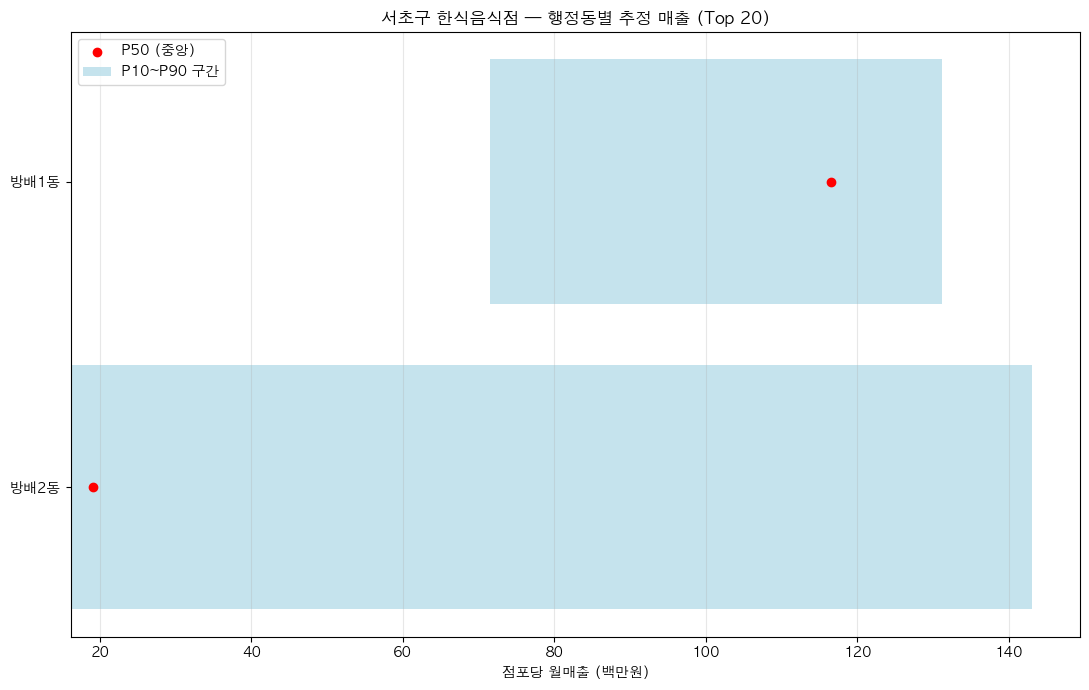

In [14]:
# 강남 한식 — 모든 행정동의 P10/P50/P90 표시
res, dist = evaluate_startup_point(lat=37.4979, lon=127.0276,
                                    biz='한식음식점', floor='1F', investment=100_000_000)
top = dist.head(20).copy()                                     # 최상위 20개 행정동
y = np.arange(len(top))

fig, ax = plt.subplots(figsize=(11, 7))
# P10~P90 신뢰구간을 가로 막대로
ax.barh(y, top['est_P90']/1e6 - top['est_P10']/1e6, left=top['est_P10']/1e6,
        color='lightblue', alpha=0.7, label='P10~P90 구간')
ax.scatter(top['est_P50']/1e6, y, color='red', zorder=10, label='P50 (중앙)')
ax.set_yticks(y); ax.set_yticklabels(top['adstrd_nm'].values)
ax.set_xlabel('점포당 월매출 (백만원)')
ax.set_title(f'{res["matched_area"]["gu"]} 한식음식점 — 행정동별 추정 매출 (Top 20)')
ax.invert_yaxis(); ax.legend(); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

## 9. 결론

| 단계 | 단위 | 모델 |
|---|---|---|
| 학습 | **행정동 (373개) × 업종(50) × 분기(24)** — 9,172행 | RF·HistGB Quantile Regression |
| 좌표 매칭 | 자치구 25개 (point-in-polygon) | pure numpy |
| 예측 | 자치구 내 모든 행정동의 P10·P50·P90 | Quantile 3종 |
| 출력 | 평균 행정동 신뢰구간 + 최고/최저 동(洞) + 자치구 내 분포 | dict + DataFrame |

### 의미
- 같은 자치구 안에서도 행정동별 매출 차이가 크다는 점이 시각·수치로 드러남
- 행정동 평균 점포 분포에 훨씬 가까운 학습 (자치구 합산이 아닌 행정동 합산÷점포수)

### 한계
- 좌표 → 행정동 직접 매칭 (point-in-polygon)은 행정동 GeoJSON 미보유로 미구현. 자치구 매칭 후 자치구 내 행정동들을 모두 보여주는 방식으로 우회.
- 실제 행정동 평균 점포 매출 분산은 행정동 단위 분산보다 더 클 수 있음 (한 동 안에서도 점포별 천차만별).

> ⚠️ **시연 결과의 내적 불일치 — 그대로 신뢰하면 안 됨**
> - **P90 < P50 역전:** 여러 시연에서 분위수 회귀의 P90 예측이 P50보다 낮게 나온다 (예: 강남역 한식 P50 114.6M인데 P90 111.9M, §7 층수 효과 표 전 행에서 P90 < P50). Q10·Q50·Q90이 독립 학습돼 단조성(monotonicity)이 보장되지 않은 결과이므로 P10·P50·P90을 신뢰구간으로 해석할 수 없다.
> - **층수 계수 미반영 의심:** `floor_multiplier`가 입력에는 표시되지만(B1=0.55 등) 일부 시연의 P10/P50/P90 산출에 일관되게 곱해지지 않아, 층수만 바꿔도 비율이 정확히 계수대로 변하지 않는다.
> - **극소 표본:** 다수 시연이 학습 표본 1~7행 위에서 돌아간다 (예: 마포 커피-음료 7행, 홍대 일반의원·잠실 치킨·용산 노래방 각 1행). 노트북 스스로 "표본 매우 부족 — 결과 참고용" 경고를 띄우며, 이 경우 P10/P50/P90 "신뢰구간"은 통계적으로 무의미하다.